# Proyecto Integrador (Hito 3): Análisis Estratégico basado en Segmentación


**Integrantes del grupo:**
- Ayelen Lujan Zapata Toledo
- Estephanie Vargas
- Ezequiel Martinez
- Magali Valiente
- Mateo Cruz


 # VISUALIZACION METRICAS A ANALIZAR


- **Ranking de clientes:** ¿qué clientes realizan más compras y cuáles generan mayores ingresos? (cantidad de pedidos vs. monto/ganancia)


 # Fase 1: Segmentación algorítmica

### LIBRERIAS A UTILIZAR

In [6]:
#Importacion de librerias y dataset

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
df = pd.read_csv('/content/Dataset_Clientes_Limpio.csv')

In [7]:
clientes_sin_compras = df[df['Cantidad_Pedidos'] == 0].copy()
df_activos = df[df['Cantidad_Pedidos'] > 0].copy()

# --- Clustering: SOLO con los clientes activos ---
X = df_activos[['Monto_Total_Comprado', 'Ganancia_Total_Generada', 'Cantidad_Pedidos']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df_activos['Cluster'] = kmeans.fit_predict(X_scaled)

# --- clientes sin compras ---
clientes_sin_compras['Cluster'] = 3

df_final = pd.concat([df_activos, clientes_sin_compras], ignore_index=True)

print('Total de clientes:', len(df_final))
print(df_final['Cluster'].value_counts().sort_index())

Total de clientes: 300
Cluster
0    120
1     50
2    119
3     11
Name: count, dtype: int64


### Resumen de clusters

In [8]:
resumen = df_final.groupby('Cluster')[['Monto_Total_Comprado', 'Ganancia_Total_Generada', 'Cantidad_Pedidos']].mean().round(2)
print(resumen)

         Monto_Total_Comprado  Ganancia_Total_Generada  Cantidad_Pedidos
Cluster                                                                 
0                     9776.69                  2968.31              2.38
1                    37675.86                 11923.37              7.54
2                    22590.34                  7145.56              4.51
3                        0.00                     0.00              0.00


### Visualización de los segmentos

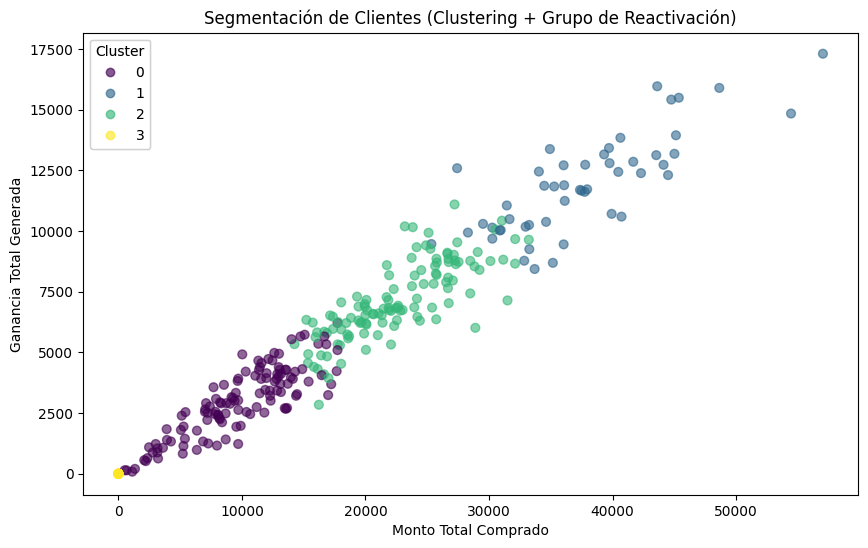

In [9]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_final['Monto_Total_Comprado'],
    df_final['Ganancia_Total_Generada'],
    c=df_final['Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=40
)

legend = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend)

plt.title('Segmentación de Clientes (Clustering + Grupo de Reactivación)')
plt.xlabel('Monto Total Comprado')
plt.ylabel('Ganancia Total Generada')
plt.show()

# Fase 2: Interpretación de segmentos

### Cluster 0 — Clientes de Alto Valor (16,3% de la base)

**Comportamiento:** clientes de compra elevada y alta frecuencia. Compran en promedio $37.757, generan $11.995 de ganancia y hacen 7-8 pedidos.

**Por qué es relevante:** aunque son solo 1 de cada 6 clientes, concentran el 32,6% de la ganancia total y el 32,2% del monto vendido por SuperTienda. Es el grupo con mayor retorno individual.

**Relación con el negocio:** son la base de ingresos más eficiente de la operación. Al tener alta frecuencia de pedidos, requieren que la logística esté siempre lista (stock disponible, entregas rápidas), porque una mala experiencia acá pega fuerte en las ganancias.

---

### Cluster 1 — Clientes Recurrentes (38,7% de la base)

**Comportamiento:** clientes de compra media, ni los que más ni los que menos gastan. Compran en promedio $22.900, generan $7.243 de ganancia y hacen 4-5 pedidos.

**Por qué es relevante:** es el grupo más numeroso entre los clientes activos y en conjunto genera casi la mitad de la ganancia total (46,6%). Es el segmento con más potencial de crecimiento.

**Relación con el negocio:** sostiene la estabilidad del negocio por su volumen. Es el público ideal para campañas de fidelización, ya que un pequeño aumento en su frecuencia de compra impacta fuerte en la ganancia total, justamente por ser tantos clientes.

---

### Cluster 2 — Clientes Ocasionales (41,3% de la base)

**Comportamiento:** clientes de compra baja pero real. Compran en promedio $9.990, generan $3.022 de ganancia y hacen 2-3 pedidos.

**Por qué es relevante:** representan el 41,3% de los clientes, pero aportan apenas el 20,8% de la ganancia total. Es el segmento con menor eficiencia comercial entre los clientes que sí compran.

**Relación con el negocio:** concentra a la mayor cantidad de clientes activos pero con el menor impacto financiero. No conviene atenderlos con el mismo esfuerzo (logístico y comercial) que al Cluster 0, sino con un enfoque más económico.

---

### Cluster 3 — Sin Compras / Candidatos a Reactivación (3,7% de la base)

**Comportamiento:** 11 clientes registrados en el sistema que nunca realizaron ninguna compra (0 pedidos, $0 de monto y ganancia).

**Por qué es relevante:** no son clientes "malos" o de bajo valor, son un problema de negocio completamente distinto: nunca se concretó la primera venta. Se excluyeron del cálculo matemático del KMeans porque mezclarlos con el Cluster 2 distorsionaba el promedio real de quienes sí compran poco.

**Relación con el negocio:** requieren una estrategia de **primera conversión**, no de fidelización ni de reactivación de compra — ya identificados en el Hito 2 como oportunidad de reactivación por región.

---

### Comparación entre segmentos

La diferencia principal entre los tres grupos de clientes activos no está en cuánto ganan por cada peso vendido (el margen es parecido en los tres), sino en **cuánto compran y con qué frecuencia**. El Cluster 3 es distinto a los otros tres: no es un problema de "poca frecuencia", es un problema de que la relación comercial nunca arrancó.

| Cluster | Nombre | % de clientes | % de la ganancia |
|---|---|---|---|
| 2 | Ocasionales | 41,3% | 20,8% |
| 1 | Recurrentes | 38,7% | 46,6% |
| 0 | Alto Valor | 16,3% | 32,6% |
| 3 | Sin Compras | 3,7% | 0% |

# Fase 3: Narrativa estratégica (C.H.I. avanzado)


### Segmento: Clientes de Alto Valor (Cluster 0)

**Contexto:** son el 16,3% de los clientes. Son los que más compran y más seguido lo hacen ($37.757 en promedio, 7-8 compras).

**Hallazgo:** encontramos que este grupo, aunque es chico, genera casi un tercio de todas las ganancias de la empresa (32,6%). Esto no se veía a simple vista, solo apareció al agrupar los datos.

**Impacto:** gran parte del dinero que gana SuperTienda depende de pocos clientes. Es bueno porque son muy rentables, pero es riesgoso: si varios de ellos se van, la empresa lo sentiría fuerte.

---

### Segmento: Clientes Recurrentes (Cluster 1)

**Contexto:** son el 38,7% de los clientes. Compran un poco, ni mucho ni poco ($22.900 en promedio, 4-5 compras).

**Hallazgo:** son el grupo más grande de clientes activos, y entre todos generan casi la mitad de las ganancias (46,6%), aunque cada uno individualmente compre menos que los de Alto Valor.

**Impacto:** este grupo sostiene el negocio todos los días. Si se los ayuda a comprar un poquito más seguido, el impacto en las ganancias sería muy grande, justamente por ser tantos.

---

### Segmento: Clientes Ocasionales (Cluster 2)

**Contexto:** son el 41,3% de los clientes. Compran poco, pero sí compraron ($9.990 en promedio, 2-3 compras).

**Hallazgo:** son el grupo con más clientes de todos, pero el que menos plata deja: solo el 20,8% de las ganancias.

**Impacto:** si la empresa les dedica el mismo esfuerzo (tiempo, atención, logística) que le dedica a los clientes de Alto Valor, está gastando de más en quienes menos retorno dan. Convendría atenderlos de una forma más simple y económica.

---

### Segmento: Clientes Sin Compras (Cluster 3)

**Contexto:** son el 3,7% de los clientes (11 personas) que están registrados en el sistema pero nunca compraron nada.

**Hallazgo:** al principio estaban mezclados con los "Ocasionales", y eso hacía parecer que ese grupo compraba menos de lo que realmente compra. Al separarlos, nos dimos cuenta de que son un caso totalmente distinto: nunca llegaron a comprar por primera vez.

**Impacto:** a este grupo no le sirve una promoción para "que compren más seguido", porque todavía no compraron ni una vez. Necesitan algo distinto: entender por qué nunca compraron y ayudarlos a hacer su primera compra.

# Fase 4: Recomendaciones accionables

### Cluster 0 — Clientes de Alto Valor (16,3% de la base)

**Recomendación 1:** darles atención preferencial (entregas más rápidas, un vendedor asignado), para que no se vayan a la competencia. Como generan el 32,6% de las ganancias, perderlos sería una gran perdida monetaria para el negocio.

**Recomendación 2:** ofrecerles productos complementarios a lo que ya compran. Como ya confían en la marca y compran seguido, es más fácil venderles algo extra a ellos que a un cliente nuevo.

---

### Cluster 1 — Clientes Recurrentes (38,7% de la base)

**Recomendación 1:** mandarles promociones simples (descuentos por segunda compra, recordatorios por el canal que mas utilicen) para que compren un poco más seguido. Como son el grupo más grande, un aumento de sus compras, generarian mas ganancias totales.

**Recomendación 2:** identificar a los que están más cerca de convertirse en "Alto Valor" (los que ya compran bastante dentro de este grupo) y ofrecerles algún beneficio extra para que puedan llegar a esa categoria.

---

### Cluster 2 — Clientes Ocasionales (41,3% de la base)

**Recomendación 1:** atenderlos por canales más económicos (web, app, mensajes automáticos) en vez de atención personalizada, ya que hoy generan poca ganancia (20,8% de la ganancia) para lo numerosos que son.

**Recomendación 2:** investigar por qué compran tan poco (¿precio, competencia, mala experiencia?) antes de invertir en campañas de marketing más caras para este grupo.

---

### Cluster 3 — Sin Compras / Candidatos a Reactivación (3,7% de la base)

**Recomendación 1:** contactarlos individualmente (son solo 11 personas) para entender por qué nunca compraron, ya que un problema puntual (por ejemplo, un error al registrarse) podría solucionarse fácil y sumar ventas nuevas.

**Recomendación 2:** ofrecerles un incentivo para su primera compra (por ejemplo, un descuento de bienvenida o envio gratis).

# Fase 5: Limitaciones del análisis



### Limitaciones de los datos
- No sabemos el día exacto de cada compra, solo el año.
- No sabemos qué productos compró cada cliente.
- El Puntaje de Fidelidad no parece reflejar cuánto compra el cliente.
- Algunos montos incluyen compras que después fueron canceladas o devueltas, por lo que las cifras podrían estar un poco más altas de lo real.

### Supuestos realizados
- Se usaron 3 datos principales para armar los grupos: cuánto gastó, cuánta ganancia generó y cuántas veces compró.
- Se armaron 4 grupos en total: 3 según el nivel de compra, y un cuarto grupo aparte para los 11 clientes que nunca compraron, para no mezclarlos con los que sí compran.
- Se asumió que los datos ya estaban limpios y correctos desde el trabajo anterior.

### Factores externos
- No se consideró la situación económica general (inflación, dólar, etc.).
- No se consideró lo que hace la competencia.
- Los datos son de un momento puntual; conviene repetir este análisis cada cierto tiempo para ver si los grupos cambian.


# Auditoría de Riesgos Éticos de la Data

Para realizar la auditoria se tomaron de referencia las preguntas basicas de etica y proteccion de datos


### 1. ¿Hay grupos con muy pocos datos?
El dataset tiene 300 clientes repartidos en 4 regiones (Austral, Centro, Norte, Sur) y 3 segmentos (Consumidor, Corporativo, Home Office)

### 2. ¿Se usan datos sensibles de las personas?
No. El dataset no tiene datos como género, edad, nivel socioeconómico ni información de contacto. Solo usamos información de compra (cuánto gastaron, cuántas veces compraron), lo que reduce el riesgo de que el modelo discrimine por características personales de cada cliente.

### 3. ¿El agrupar clientes puede perjudicar a alguien?
Sí, hay un riesgo a tener en cuenta: clasificar a los clientes en "Alto Valor" y "Ocasionales" podría llevar a que los clientes que ya compran poco reciban todavía menos atención, empeorando la situación en vez de mejorarla. Por eso, nuestras recomendaciones es no dejar de atender a ningún grupo, pero darle prioridad a los clientes potenciales.

### 4. ¿Los datos usados son confiables?
Hay un punto importante para aclarar: `Monto_Total_Comprado` y `Ganancia_Total_Generada` incluyen pedidos que fueron cancelados o devueltos, no solo los completados (esto viene heredado de una limitación del Hito 1). Esto significa que los montos usados para armar los clusters podrían estar un poco inflados, esto es asi ya que no se tomaron parametros tan detallados.

### 5. ¿Se excluyó a algún cliente del análisis, y por qué?
Sí: separamos a 11 clientes que nunca hicieron ninguna compra, y los tratamos como un grupo aparte ("Sin Compras / Candidatos a Reactivación") en vez de mezclarlos con los que compran poco. Esta decisión no los perjudica ni los excluye del análisis — al contrario, evita que queden "invisibles" dentro de otro grupo, y les da una recomendación pensada específicamente para su situación.

### Conclusión de la auditoría
No encontramos riesgos éticos graves. Los puntos identificados se pueden manejar siendo transparentes al comunicar los resultados, y diseñando las recomendaciones de forma que ayuden a todos los segmentos, sin dejar a ninguno peor de lo que estaba.